# Классификация

на основе iris.dataset

In [ ]:
from sklearn import datasets

iris = datasets.load_iris(as_frame=True)
df = iris.data
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


# Часть 1:

Корреляции между признаками на всей таблице.

In [ ]:
df.drop(columns=['target', 'species']).corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


высокий уровень **положительной** корреляции между:
  - (sepal length и petal length) - 0.87,
  - (sepal length и petal width) - 0.82,
  - (petal length и petal width) - 0.96.
<br>

**Положительная корреляция** показывает, что показатели *признаков меняются совместно*, т.е. если растёт одна переменная, то растёт и другая (и наоборот)


**Отрицательная корреляция** означает, что две *переменные изменяются в противоположных направлениях*: при увеличении одной переменной, другая уменьшается, и наоборот.



---



---



Корреляция для класса 0 (setosa)

In [ ]:
df.loc[df['target'] == 0].drop(columns=['target', 'species']).corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,0.742547,0.267176,0.278098
sepal width (cm),0.742547,1.000000,0.177700,0.232752
petal length (cm),0.267176,0.177700,1.000000,0.331630
petal width (cm),0.278098,0.232752,0.331630,1.000000


Корреляция для класса 1 (versicolor)

In [ ]:
df.loc[df['target'] == 1].drop(columns=['target', 'species']).corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,0.525911,0.754049,0.546461
sepal width (cm),0.525911,1.000000,0.560522,0.663999
petal length (cm),0.754049,0.560522,1.000000,0.786668
petal width (cm),0.546461,0.663999,0.786668,1.000000


Корреляция для класса 2 (virginica)

In [ ]:
df.loc[df['target'] == 2].drop(columns=['target', 'species']).corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,0.457228,0.864225,0.281108
sepal width (cm),0.457228,1.000000,0.401045,0.537728
petal length (cm),0.864225,0.401045,1.000000,0.322108
petal width (cm),0.281108,0.537728,0.322108,1.000000


Вывод: корреляция по классам разная, следовательно, мы может предполагать, что данные разделимы.



---



## Визуализация распределения классов для всех пар признаков

In [ ]:
import seaborn as sb
import matplotlib.pyplot as plt

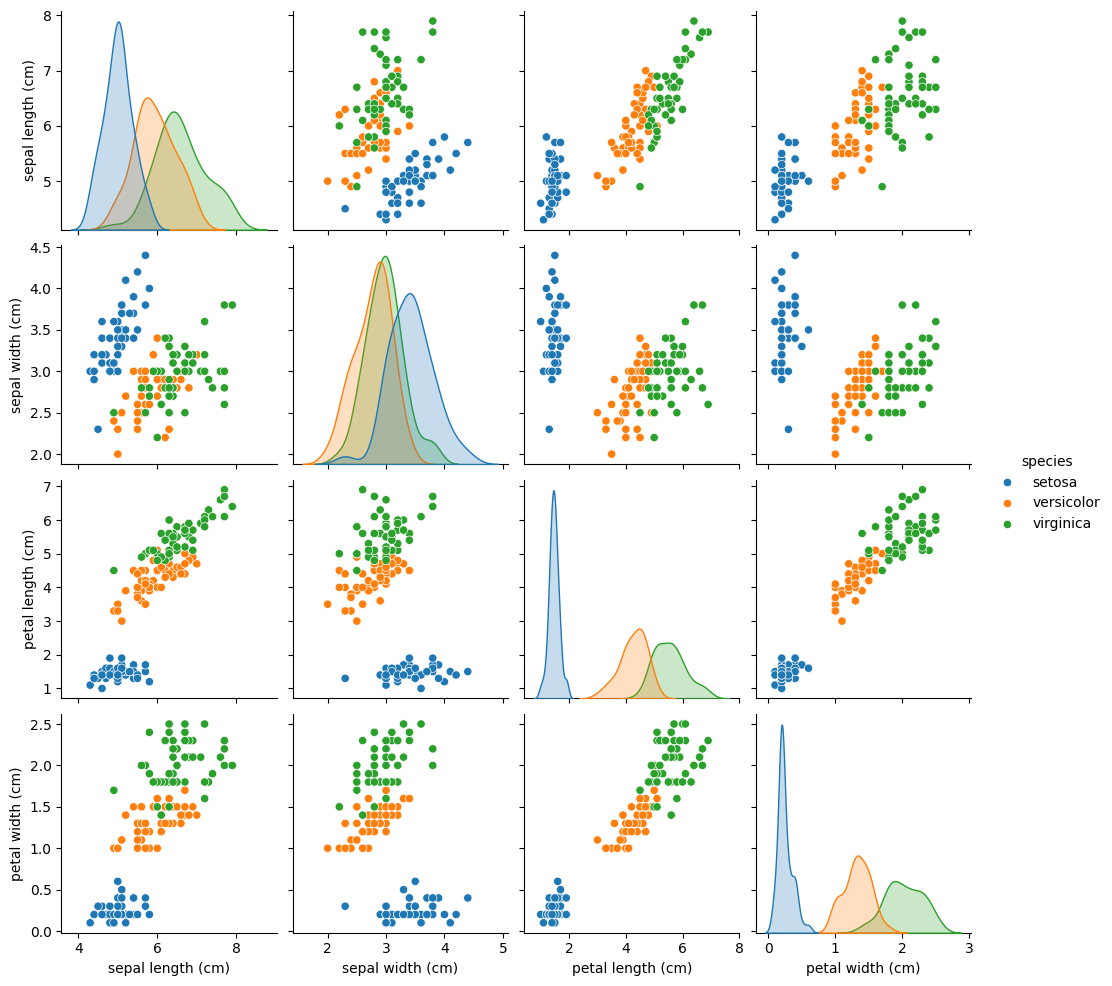

In [ ]:
sb.pairplot(df.drop(columns=['target']), hue ='species')



---



Благодяря построению графиков видно, что класс 0 (setosa) наиболее отделим от двух других. Особенно легко его можно отделить по соотношению признаков petal length и petal width.

Также визуально показано как пересекаются классы 1 и 2.



---



---



# Часть 2:

Построение и визуализация (разделяющей кривой) решений следующими методами: линейный и квадратичный дискриминант, логистическая регрессия, SVM (линейное и квадратичное ядро).

In [ ]:
# будем использовать petal length и petal width
iris = datasets.load_iris()
X = iris.data[:, 2:]

In [ ]:
df_new = df.drop(columns=['sepal length (cm)', 'sepal width (cm)'])



---



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score

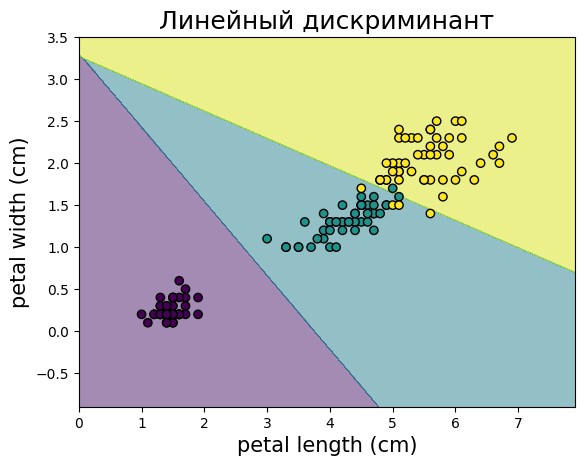

Accuracy =  0.96
Balanced accuracy =  0.96


In [ ]:
lda = LinearDiscriminantAnalysis(solver='lsqr').fit(X, df_new.target)
# lsqr — метод наименьших квадратов
disp = DecisionBoundaryDisplay.from_estimator(
     lda, X, response_method="predict",
     alpha=0.5, grid_resolution=1000)
disp.ax_.scatter(X[:, 0], X[:, 1], c=df_new.target, edgecolor="k")
plt.xlabel('petal length (cm)', fontsize=15)
plt.ylabel('petal width (cm)', fontsize=15)
plt.title('Линейный дискриминант', fontsize=18)
plt.show()
acc = accuracy_score(df_new.target, lda.predict(X))
balanced_acc = balanced_accuracy_score(df_new.target, lda.predict(X))
print('Accuracy = ', acc)
print('Balanced accuracy = ', balanced_acc)

Важно! Метод чувствителен к выбросам.



---



In [ ]:
from sklearn.linear_model import LogisticRegression

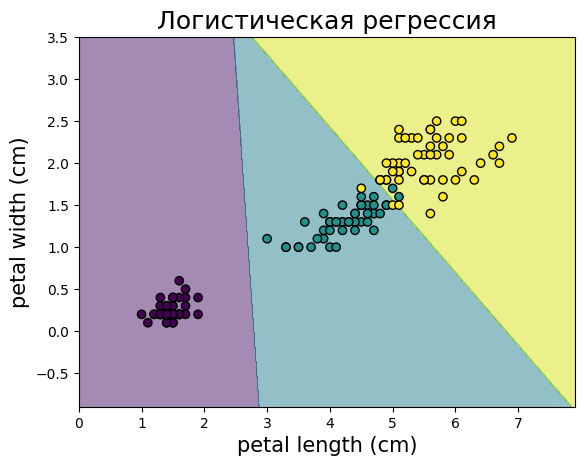

Balanced accuracy =  0.9666666666666667


In [ ]:
lr = LogisticRegression().fit(X, df_new.target)
disp = DecisionBoundaryDisplay.from_estimator(
     lr, X, response_method="predict",
     alpha=0.5, grid_resolution=1000)
disp.ax_.scatter(X[:, 0], X[:, 1], c=df_new.target, edgecolor="k")
plt.xlabel('petal length (cm)', fontsize=15)
plt.ylabel('petal width (cm)', fontsize=15)
plt.title('Логистическая регрессия', fontsize=18)
plt.show()
balanced_acc = balanced_accuracy_score(df_new.target, lr.predict(X))
print('Balanced accuracy = ', balanced_acc)

Важно! Корреляция между petal length и petal width = 0.96. Сильная корреляция между признаками может снизить надёжность модели.



---



In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

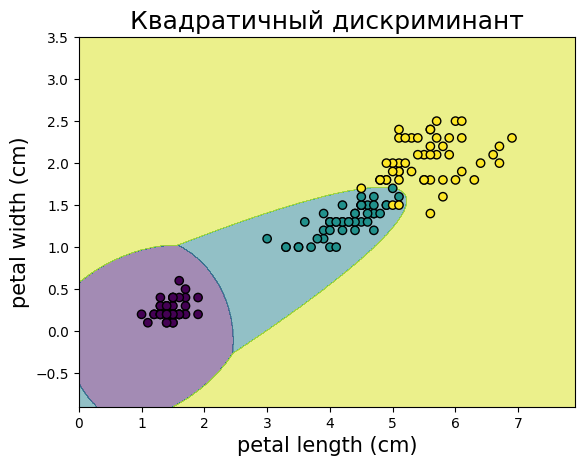

Balanced accuracy =  0.98


In [ ]:
qda = QuadraticDiscriminantAnalysis().fit(X, df_new.target)
disp = DecisionBoundaryDisplay.from_estimator(
     qda, X, response_method="predict",
     alpha=0.5, grid_resolution=1000)
disp.ax_.scatter(X[:, 0], X[:, 1], c=df_new.target, edgecolor="k")
plt.xlabel('petal length (cm)', fontsize=15)
plt.ylabel('petal width (cm)', fontsize=15)
plt.title('Квадратичный дискриминант', fontsize=18)
plt.show()
balanced_acc = balanced_accuracy_score(df_new.target, qda.predict(X))
print('Balanced accuracy = ', balanced_acc)

Важно! Используем, если классы имеют разные структуры разброса (разные ковариационные матрицы)



---



In [ ]:
from sklearn.svm import SVC

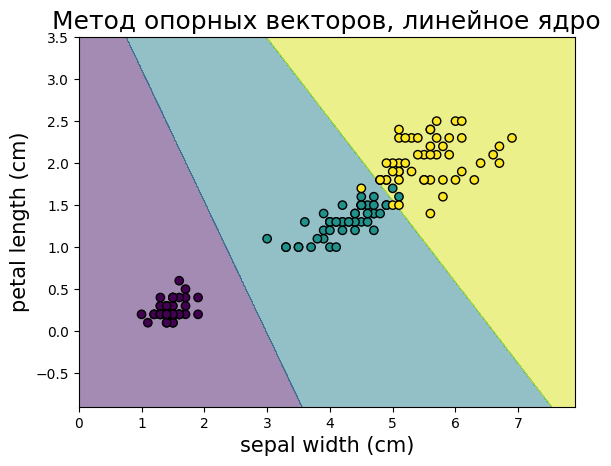

Balanced accuracy =  0.9666666666666667


In [ ]:
clf = SVC(kernel='linear').fit(X, df_new.target)
disp = DecisionBoundaryDisplay.from_estimator(
     clf, X, response_method="predict",
     alpha=0.5, grid_resolution=1000)
disp.ax_.scatter(X[:, 0], X[:, 1], c=df_new.target, edgecolor="k")
plt.xlabel('sepal width (cm)', fontsize=15)
plt.ylabel('petal length (cm)', fontsize=15)
plt.title('Метод опорных векторов, линейное ядро', fontsize=18)
plt.show()
balanced_acc = balanced_accuracy_score(df_new.target, clf.predict(X))
print('Balanced accuracy = ', balanced_acc)



---



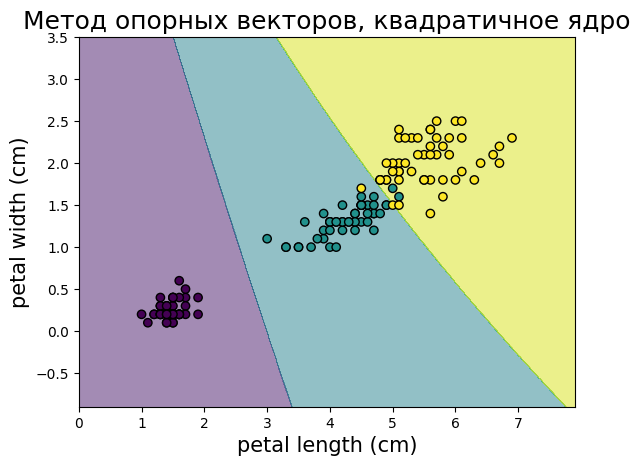

Balanced accuracy =  0.9666666666666667


In [ ]:
clf_q = SVC(kernel='poly', degree=2).fit(X, df_new.target)
disp = DecisionBoundaryDisplay.from_estimator(
     clf_q, X, response_method="predict",
     alpha=0.5, grid_resolution=1000)
disp.ax_.scatter(X[:, 0], X[:, 1], c=df_new.target, edgecolor="k")
plt.xlabel('petal length (cm)', fontsize=15)
plt.ylabel('petal width (cm)', fontsize=15)
plt.title('Метод опорных векторов, квадратичное ядро', fontsize=18)
plt.show()
balanced_acc = balanced_accuracy_score(df_new.target, clf_q.predict(X))
print('Balanced accuracy = ', balanced_acc)



---



Вывод: на основе показателя accuracy можно сделать вывод о том, что модель на основе квадратичного дискриминанта подходит для решения нашей задачи больше других.

Balanced accuracy:

0.96 - Линейный дискриминант

0.97 - Логистическая регрессия, Метод опорных векторов (линейное и квадратичное ядро)

0.98 - Квадратичный дискриминант



---



---



# Часть 3:

В следующих пунктах оставим только два наименее разделимых класса (это классы 1 и 2)

Построим линейный дискриминант на всех объектах. Визуализируем ответы алгоритма и классы объектов во всех двумерных подпространствах признаков.

In [ ]:
task_3 = df.loc[df['species'] != 'setosa'].reset_index(drop=True)

In [ ]:
task_3

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,7.0,3.2,4.7,1.4,1,versicolor
1,6.4,3.2,4.5,1.5,1,versicolor
2,6.9,3.1,4.9,1.5,1,versicolor
3,5.5,2.3,4.0,1.3,1,versicolor
4,6.5,2.8,4.6,1.5,1,versicolor
...,...,...,...,...,...,...
95,6.7,3.0,5.2,2.3,2,virginica
96,6.3,2.5,5.0,1.9,2,virginica
97,6.5,3.0,5.2,2.0,2,virginica
98,6.2,3.4,5.4,2.3,2,virginica


In [ ]:
from collections import Counter
cnt = Counter(df['target'])
cnt

Counter({0: 50, 1: 50, 2: 50})

In [ ]:
X = iris.data[:, :][50:]

In [ ]:
X.shape

(100, 4)

In [ ]:
lda_2_classes = LinearDiscriminantAnalysis().fit(X, task_3.target)

In [ ]:
preds = lda_2_classes.predict(X)

In [ ]:
type(preds[0])

numpy.int64

In [ ]:
real_targets = list(task_3.target)

In [ ]:
vers_tp = []
vers_fp = []

virg_tp = []
virg_fp = []

for i in range(50):
  if preds[i] == 1:
    vers_tp.append(i) # буду записывать индекс, чтобы потом обратиться
  else:
    vers_fp.append(i)

for i in range(50, 100):
  if preds[i] == 2:
    virg_tp.append(i)
  else:
    virg_fp.append(i)


In [ ]:
X[1][0]

6.4

In [ ]:
X[0][0]

7.0

In [ ]:
col_names = task_3.drop(columns=['target',	'species']).columns

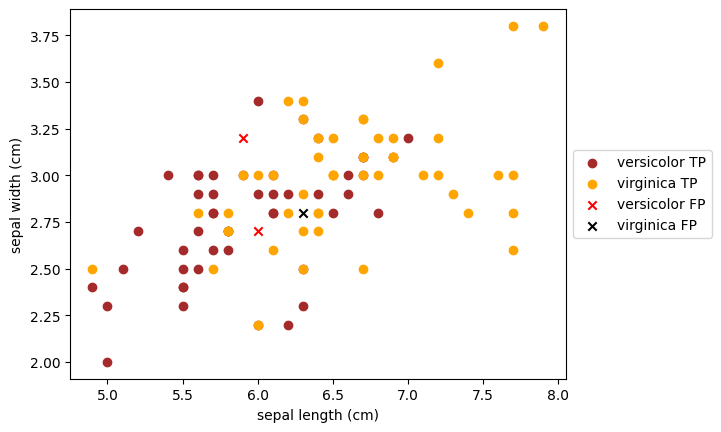

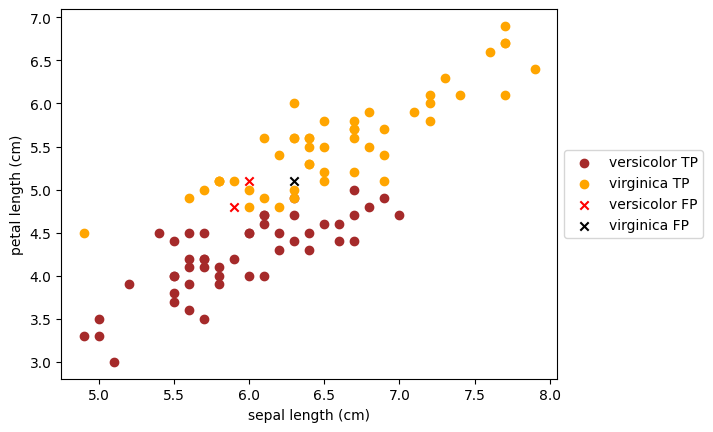

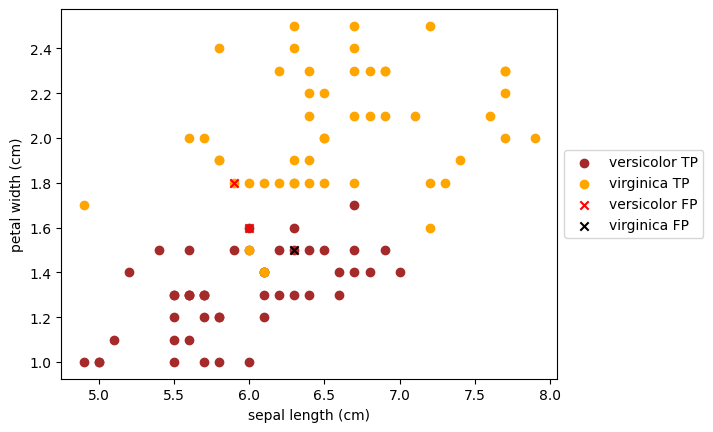

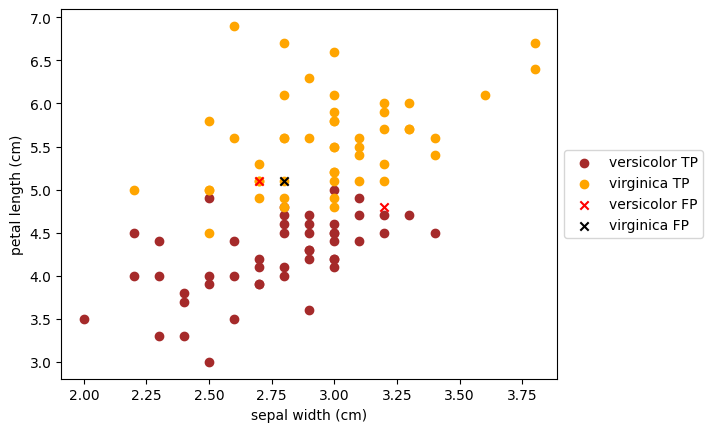

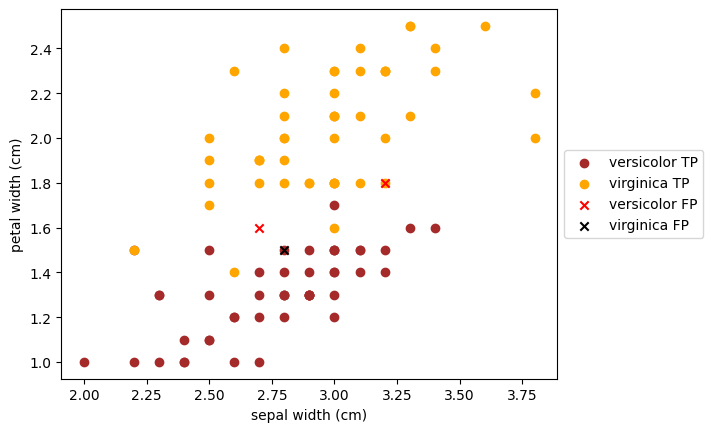

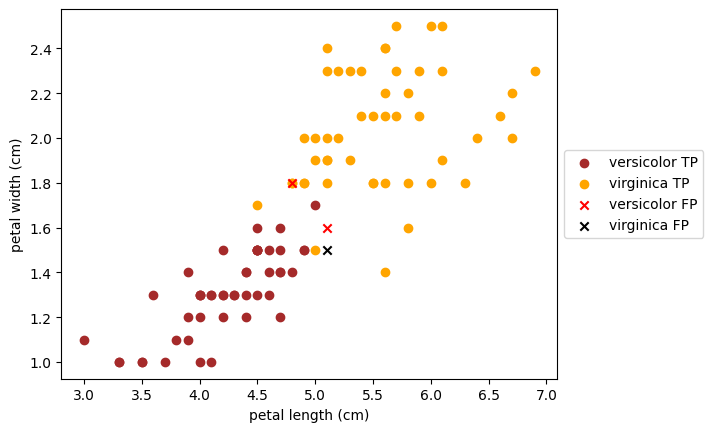

In [ ]:
for f_1 in range(4):
  for f_2 in range(f_1, 4):
    if f_1 == f_2:
      continue

    for i in vers_tp:
      plt.scatter(X[i][f_1], X[i][f_2],
              color='brown',
              label='versicolor TP'
              )

    for i in virg_tp:
      plt.scatter(X[i][f_1], X[i][f_2],
              color='orange',
              label='virginica TP'
              )

    for i in vers_fp:
      plt.scatter(X[i][f_1], X[i][f_2],
              color='red',
              marker='x',
              label='versicolor FP'
              )

    for i in virg_fp:
      plt.scatter(X[i][f_1], X[i][f_2],
              color='black',
              marker='x',
              label='virginica FP'
              )

    handles, labels = plt.gca().get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    plt.legend(*zip(*unique), loc='center left', bbox_to_anchor=(1, 0.5))

    plt.xlabel(col_names[f_1])
    plt.ylabel(col_names[f_2])
    plt.show()

In [ ]:
print('Accuracy versicolor = ', len(vers_tp)/50)
print('Accuracy virginica = ', len(virg_tp)/50)

Accuracy versicolor =  0.96
Accuracy virginica =  0.98




---



Вывод: после визуализации, а также проверки качества, видим, что модель на основе линейного дискриминанта лучше распознаёт класс virginica (всего одна ошибка)



---



---



# Часть 4:

На двух переменных из пункта 2 вычислим квадратичную разделяющую функцию по оценкам ковариационных матриц и средних (реализуем метод самостоятено - не используем готовый). Визуализируем её и сравним с решением из пункта 2.

Используемые признаки: petal length и petal width

In [ ]:
# from sklearn import datasets
import numpy as np
# import matplotlib.pyplot as plt

In [ ]:
iris = datasets.load_iris()
data = iris.data[:, 2:][50:]

In [ ]:
class_1_l = data[:, 0][:50]
class_2_l = data[:, 0][50:]

class_1_w = data[:, 1][:50]
class_2_w = data[:, 1][50:]

In [ ]:
class_1_l.shape, class_1_w.shape, class_2_l.shape, class_2_w.shape

((50,), (50,), (50,), (50,))

In [ ]:
# центроиды
mu = np.array([class_1_l.mean(), class_1_w.mean()])
nu = np.array([class_2_l.mean(), class_2_w.mean()])

# ков. матрицы
sigma = np.cov(np.array([class_1_l, class_1_w]))
lamda = np.cov(np.array([class_2_l, class_2_w]))

# априорные вероятности
P_1 = len(data[:50])/len(data)
P_2 = len(data[50:])/len(data)

In [ ]:
mu, nu, sigma, lamda, P_1, P_2

(array([4.26 , 1.326]),
 array([5.552, 2.026]),
 array([[0.22081633, 0.07310204],
        [0.07310204, 0.03910612]]),
 array([[0.30458776, 0.04882449],
        [0.04882449, 0.07543265]]),
 0.5,
 0.5)

In [ ]:
def Q(x, cov_matrix, centroid):
  a = x-centroid
  return a.T@np.linalg.inv(cov_matrix)@a

In [ ]:
def l_0(x):
  return 0.5*(Q(x, lamda, nu)-Q(x, sigma, mu))+np.log(
      np.sqrt(np.linalg.det(lamda))/np.sqrt(np.linalg.det(sigma))
      ) + np.log(P_1/P_2)

In [ ]:
l_0(data[99]), l_0(data[35])

(0.8434261284058086, 1.101436352079278)

In [ ]:
xx, yy = np.meshgrid(
    np.arange(data[:, 0].min()-0.5, data[:, 0].max()+0.5, 0.01),
    np.arange(data[:, 1].min()-0.5, data[:, 1].max()+0.5, 0.01)
    )

In [ ]:
def new_func(x):
  n = x.shape[0]
  a = np.zeros((n, 1))
  for i in range(n):
    val = l_0(x[i])
    if val < 0:
      a[i] = 1
    else:
      a[i] = 0
  return a

In [ ]:
Z = new_func(np.c_[xx.ravel(), yy.ravel()])

In [ ]:
Z = Z.reshape(xx.shape)

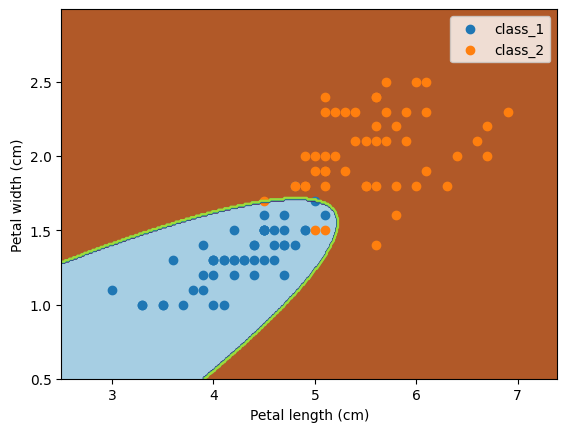

In [ ]:
plt.contour(xx, yy, Z)
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, shading = 'gouraud')
plt.scatter(data[:50][:, 0], data[:50][:, 1], label='class_1')
plt.scatter(data[50:][:, 0], data[50:][:, 1], label='class_2')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.legend()
plt.show()



---



In [ ]:
# from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [ ]:
targets = iris['target'][50:]
qda_4 = QuadraticDiscriminantAnalysis().fit(data, targets)
Z_qda = qda_4.predict(np.c_[xx.ravel(), yy.ravel()])
Z_qda = Z_qda.reshape(xx.shape)

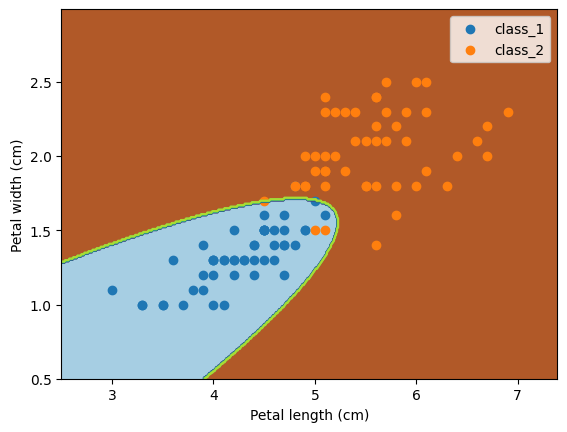

In [ ]:
plt.contour(xx, yy, Z_qda)
plt.pcolormesh(xx, yy, Z_qda, cmap=plt.cm.Paired, shading = 'gouraud')
plt.scatter(data[:50][:, 0], data[:50][:, 1], label='class_1')
plt.scatter(data[50:][:, 0], data[50:][:, 1], label='class_2')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.legend()
plt.show()



---



Вывод: вручную был реализован метод вычисления квадратичной разделяющей функции по оценкам ковариационных матриц и средних. Также проведено сравнение с готовой моделью на основе квадратичного дискриминанта библиотеки sklearn. Графики разделяющих кривых оказались идентичными. Соответственно, готовую модель использовать целесообразнее для экономии времени и усилий.